# Billar diferenciable

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana04_billar_FD.ipynb)

Veamos una idea central de la física diferenciable con PyTorch: en lugar de aprender parámetros de una red, optimizamos las **condiciones iniciales** de un sistema físico.

El objetivo será elegir:

- la posición inicial de la bola blanca,
- su velocidad inicial,

de modo que, después de muchas colisiones, una bola objetivo termine lo más cerca posible de un punto marcado sobre la mesa.

## El problema de optimización

Planteamos el problema de optimización en función de una función de costo que mide que tan lejos queda la bola objetivo del punto deseado. Para esto, tenemos que tener un simulador que realiza la dinámica hacia adelante, que actualiza posiciones y velocidades de las distintas bolas de billar a medida que pasa el tiempo. Esta evolución temporal dependerá de la posición inicial $x_0$ $de la bola blanca, y de su vector velocidad $v_0$.  

En símbolos:

$$\text{estado final} = \mathrm{Simular}(x_0, v_0)$$

$$L(x_0, v_0) = \|x_{\text{objetivo}}^{\text{final}} - x_{\text{meta}}\|^2$$

Construiremos a toda la simulación con operaciones de `torch`, de modo tal que PyTorch podrá calcular los gradientes de nuestra función de costo $L$ respecto de $x_0$ y $v_0$.

In [2]:
import math
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
real = torch.float32

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["axes.titlesize"] = 12

print("dispositivo:", device)

dispositivo: cpu


## Planteo de la geometría de la escena

Trabajamos en una mesa cuadrada normalizada al rango $[0, 1] \times [0, 1]$.

- La bola blanca será la bola `0`.
- El resto de las bolas arrancan en una formación triangular.
- La última bola de esa formación será la **bola objetivo**.
- El punto negro marca la posición final deseada.

In [34]:
steps = 1024 # pasos a simular
dt = 0.003 # intervalo de tiempo del paso
radius = 0.03 # de las bolas
elasticity = 0.8 # cuanto pierde la bola al chocar con otra o con la pared (1.0 es sin perdida de energia, 0.0 es sin rebote)


billiard_layers = 3
n_balls = 1 + (1 + billiard_layers) * billiard_layers // 2
target_ball = n_balls - 1

# Punto objetivo al que queremos llevar la bola azul
goal = torch.tensor([0.88, 0.75], device=device, dtype=real)


# donde comienza la bola blanca y con qué velocidad
default_init_x = torch.tensor([0.10, 0.50], device=device, dtype=real)
default_init_v = torch.tensor([0.30, 0.00], device=device, dtype=real)

COLOR_TABLERO = "#3C733F"
COLOR_BOLA_BLANCA = "#DDDDDD"
COLOR_BOLA_OBJETIVO = "#3344CC"
COLOR_BOLA = "#F20530"
COLOR_OBJETIVO = "#000000"


def build_rack():
    """Arma el rack de bolas, posicion inicial"""
    rack = []
    for i in range(billiard_layers):
        for j in range(i + 1):
            rack.append([
                i * 2 * radius + 0.5,
                j * 2 * radius + 0.5 - i * radius * 0.7,
            ])
    return torch.tensor(rack, device=device, dtype=real)


# armamos las posiciones inciales
POSICIONES_RACK = build_rack()


# agrega bola blanca
def build_table_state(cue_pos):
    return torch.cat([cue_pos.reshape(1, 2), POSICIONES_RACK], dim=0)


# arma la escena
def render_scene(pos, title=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    fig.patch.set_facecolor(COLOR_TABLERO)
    ax.set_facecolor(COLOR_TABLERO)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.add_patch(Circle((goal[0].item(), goal[1].item()), radius, color=COLOR_OBJETIVO))

    pos_np = pos.detach().cpu().numpy()
    for i in range(n_balls):
        if i == 0:
            color = COLOR_BOLA_BLANCA
        elif i == target_ball:
            color = COLOR_BOLA_OBJETIVO
        else:
            color = COLOR_BOLA
        ax.add_patch(Circle((pos_np[i, 0], pos_np[i, 1]), radius, color=color))

    if title is not None:
        ax.set_title(title)
    return ax

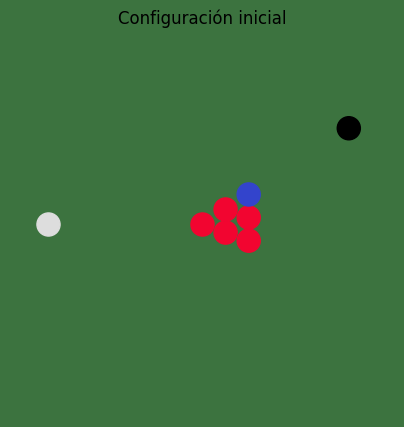

In [35]:
initial_table = build_table_state(default_init_x)
render_scene(initial_table, title="Configuración inicial")
plt.show()

## Dinámica y colisiones

La simulación usa un esquema explícito muy simple:

1. predecimos si dos bolas van a superponerse en el próximo paso,
2. calculamos un impulso correctivo según la velocidad relativa,
3. actualizamos velocidad y posición.

Esto es un simulador muy idealizado; es una versión compacta, suficiente para estudiar la idea de optimización con gradientes.

In [ ]:
def initialize_state(init_x, init_v):
    pos = build_table_state(init_x)
    vel = torch.cat(
        [
            init_v.reshape(1, 2),
            torch.zeros((n_balls - 1, 2), device=device, dtype=real),
        ],
        dim=0,
    )
    return pos, vel


def collide(pos, vel):
    # calculamos la posicio futura de cada bola
    predicted_pos = pos + dt * vel
    
    # calculamos distancia entre cada par de bolas
    delta = predicted_pos[:, None, :] - predicted_pos[None, :, :]
    dist = torch.linalg.norm(delta, dim=-1)
    
    # calculamos dirección de la colisión
    direction = delta / dist.clamp_min(1e-6).unsqueeze(-1)

    # calculamos velocidad relativa entre cada par de bolas
    relative_velocity = vel[:, None, :] - vel[None, :, :]
    
    # proyectamos sobre la direccion de colision
    projected_velocity = (direction * relative_velocity).sum(dim=-1)

    # solo consideramos colisiones entre bolas distintas, que estén lo suficientemente cerca, y que se estén acercando
    valid_pairs = ~torch.eye(n_balls, device=device, dtype=torch.bool)
    colliding = (dist < 2 * radius) & (projected_velocity < 0) & valid_pairs

    # calculamos el momento o impulso en cada colision
    impulse_pair = (-(1 + elasticity) * 0.5 * projected_velocity).unsqueeze(-1) * direction
    impulse_pair = torch.where(colliding.unsqueeze(-1), impulse_pair, torch.zeros_like(impulse_pair))

    # para evitar que las bolas se "atraviesen" entre sí, calculamos el tiempo de impacto y corregimos la posición
    min_projected_velocity = torch.minimum(projected_velocity, torch.full_like(projected_velocity, -1e-3))
    time_of_impact = (dist - 2 * radius) / min_projected_velocity
    position_correction = torch.minimum(time_of_impact - dt, torch.zeros_like(time_of_impact)).unsqueeze(-1)
    position_correction = position_correction * impulse_pair

    # sumamos los impulsos de todas las colisiones para cada bola, y lo mismo con las correcciones de posición
    impulse = impulse_pair.sum(dim=1)
    x_inc = position_correction.sum(dim=1)
    return impulse, x_inc


def simulate(init_x, init_v, save_history=False):
    pos, vel = initialize_state(init_x, init_v)
    history = [pos.detach().cpu().clone()] if save_history else None

    for _ in range(1, steps):
        impulse, x_inc = collide(pos, vel)
        vel = vel + impulse
        pos = pos + dt * vel + x_inc

        if save_history:
            history.append(pos.detach().cpu().clone())

    loss = ((pos[target_ball] - goal) ** 2).sum()
    return loss, pos, history

## Primer experimento: tiro inicial sin optimizar

Antes de optimizar nada, probamos una velocidad horizontal sencilla. Eso nos da una referencia para comparar.

pérdida inicial: 0.051202


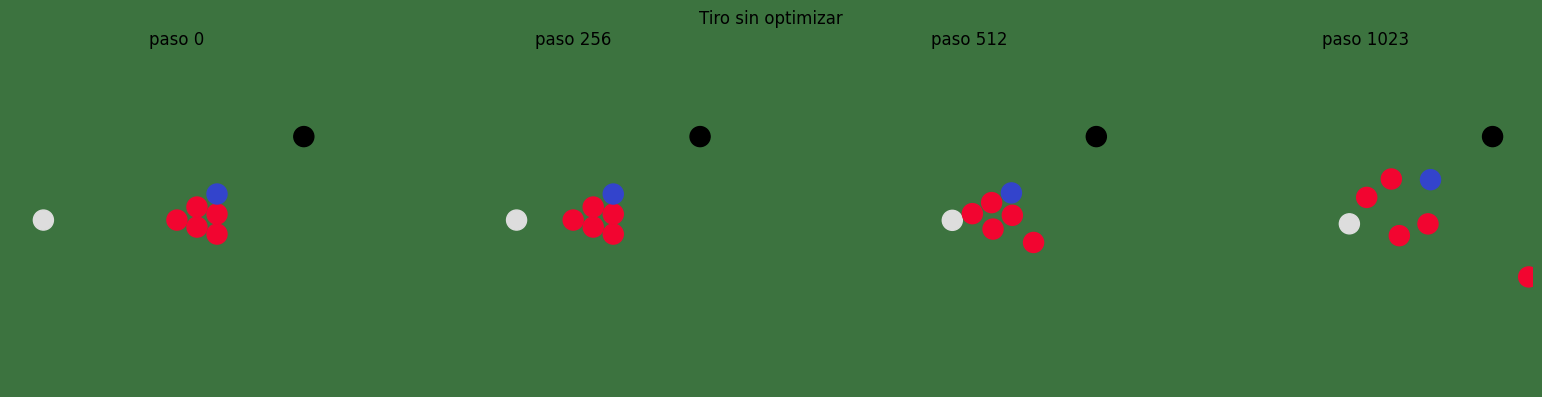

In [39]:
def show_snapshots(history, title, frame_ids):
    fig, axes = plt.subplots(1, len(frame_ids), figsize=(4 * len(frame_ids), 4))
    if len(frame_ids) == 1:
        axes = [axes]
    for ax, frame_id in zip(axes, frame_ids):
        render_scene(history[frame_id], title=f"paso {frame_id}", ax=ax)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


baseline_loss, baseline_final_pos, baseline_history = simulate(default_init_x, default_init_v, save_history=True)
print(f"pérdida inicial: {baseline_loss.item():.6f}")
show_snapshots(baseline_history, "Tiro sin optimizar", [0, 256, 512, 1023])


Pruebo con otras condiciones iniciales para ver

pérdida inicial: 0.082124


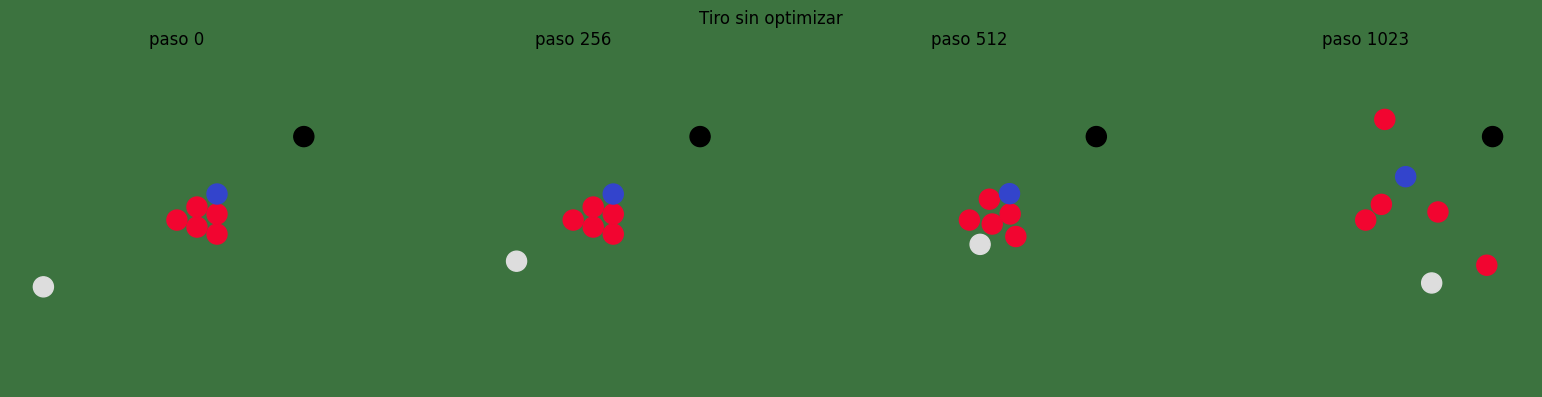

In [46]:
baseline_loss, baseline_final_pos, baseline_history = simulate(default_init_x+ torch.tensor([0.0,-0.2]),
                                                               default_init_v+ torch.tensor([0.0,0.1]),
                                                               save_history=True)
print(f"pérdida inicial: {baseline_loss.item():.6f}")
show_snapshots(baseline_history, "Tiro sin optimizar", [0, 256, 512, 1023])

## Función objetivo

Una forma de intuir la dificultad del problema es variar solo el **ángulo** de la velocidad inicial, manteniendo constante su módulo.

Si la curva tiene muchos valles o zonas planas, optimizar no será trivial.

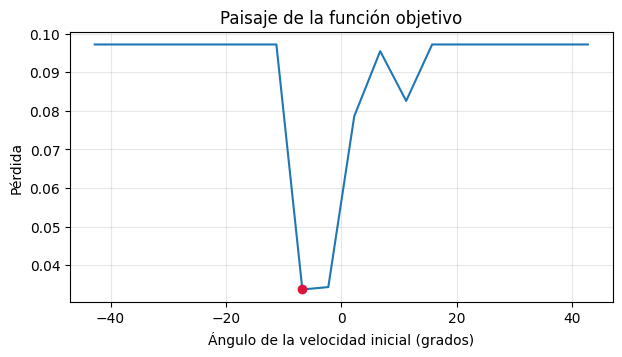

mejor ángulo dentro del barrido: -6.75 grados
mejor pérdida dentro del barrido: 0.033761


In [50]:
def scan_angles(num_angles=80, zoom=1.2):
    losses = []
    angles_deg = []

    speed = torch.linalg.norm(default_init_v).item()
    for i in range(num_angles):
        angle = ((i + 0.5) / num_angles - 0.5) * math.pi * zoom
        init_v = torch.tensor(
            [speed * math.cos(angle), speed * math.sin(angle)],
            device=device,
            dtype=real,
        )
        loss, _, _ = simulate(default_init_x, init_v, save_history=False)
        losses.append(loss.item())
        angles_deg.append(math.degrees(angle))

    best_idx = min(range(len(losses)), key=lambda i: losses[i])
    return angles_deg, losses, best_idx


angles_deg, losses, best_idx = scan_angles(num_angles=20, zoom=0.5)

plt.figure(figsize=(7, 3.5))
plt.plot(angles_deg, losses)
plt.scatter([angles_deg[best_idx]], [losses[best_idx]], color="crimson", zorder=3)
plt.xlabel("Ángulo de la velocidad inicial (grados)")
plt.ylabel("Pérdida")
plt.title("Paisaje de la función objetivo")
plt.grid(alpha=0.3)
plt.show()

print(f"mejor ángulo dentro del barrido: {angles_deg[best_idx]:.2f} grados")
print(f"mejor pérdida dentro del barrido: {losses[best_idx]:.6f}")

In [63]:
default_init_x

tensor([0.1000, 0.5000])

In [58]:
import numpy as np
def scan_x_angles(num_y=60, num_angles=80, y_min=0.02, y_max=0.30, zoom=0.5):
    losses = []
    angles_deg = []
    y_values = []

    speed = torch.linalg.norm(default_init_v).item()
    x0 = default_init_x[0].item()

    for iy in range(num_y):
        y = y_min + (iy + 0.5) * (y_max - y_min) / num_y
        row_losses = []

        for ia in range(num_angles):
            angle = ((ia + 0.5) / num_angles - 0.5) * math.pi * zoom

            init_x = torch.tensor([x0, y], device=device, dtype=real)
            init_v = torch.tensor(
                [speed * math.cos(angle), speed * math.sin(angle)],
                device=device,
                dtype=real,
            )

            loss, _, _ = simulate(init_x, init_v, save_history=False)
            row_losses.append(loss.item())

            if iy == 0:
                angles_deg.append(math.degrees(angle))

        losses.append(row_losses)
        y_values.append(y)

    losses = np.array(losses)  # shape: [num_x, num_angles]

    best_flat_idx = np.argmin(losses)
    best_y_idx, best_angle_idx = np.unravel_index(best_flat_idx, losses.shape)

    return y_values, angles_deg, losses, best_y_idx, best_angle_idx


In [65]:
x_values, angles_deg, losses_2d, best_x_idx, best_angle_idx = scan_x_angles(
    num_y=20,
    num_angles=20,
    y_min=0.3,
    y_max=0.7,
    zoom=0.5,
)

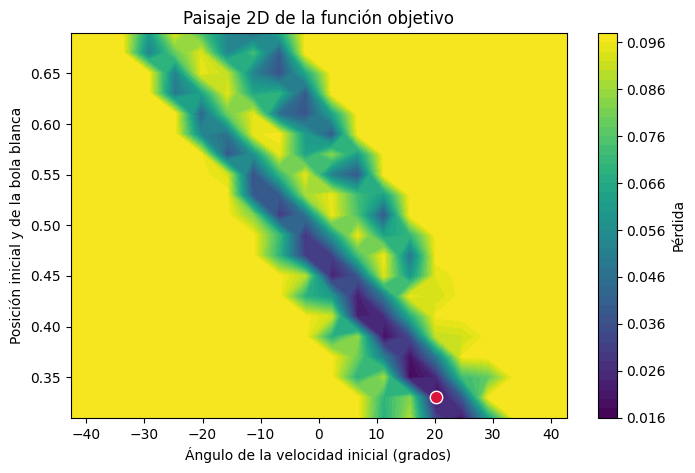

mejor y dentro del barrido: 0.3300
mejor ángulo dentro del barrido: 20.25 grados
mejor pérdida dentro del barrido: 0.016084


In [66]:
X, A = np.meshgrid(angles_deg, x_values)

plt.figure(figsize=(8, 5))
contour = plt.contourf(X, A, losses_2d, levels=40, cmap="viridis")
plt.colorbar(contour, label="Pérdida")

plt.scatter(
    [angles_deg[best_angle_idx]],
    [x_values[best_x_idx]],
    color="crimson",
    edgecolor="white",
    s=80,
    zorder=3,
)

plt.xlabel("Ángulo de la velocidad inicial (grados)")
plt.ylabel("Posición inicial y de la bola blanca")
plt.title("Paisaje 2D de la función objetivo")
plt.show()

print(f"mejor y dentro del barrido: {x_values[best_x_idx]:.4f}")
print(f"mejor ángulo dentro del barrido: {angles_deg[best_angle_idx]:.2f} grados")
print(f"mejor pérdida dentro del barrido: {losses_2d[best_x_idx, best_angle_idx]:.6f}")

In [71]:
y = x_values[best_x_idx]
x = default_init_x[0].item()

init_x1 = torch.tensor([x, y], device=device, dtype=real)

speed = torch.linalg.norm(default_init_v).item()
angle_deg = angles_deg[best_angle_idx]
angle = math.radians(angle_deg)

init_v1 = torch.tensor(
    [speed * math.cos(angle), speed * math.sin(angle)],
    device=device,
    dtype=real,
)

## Optimización con gradientes

Ahora dejamos que `torch.autograd` calcule derivadas de la pérdida respecto de:

- `init_x`: posición inicial de la bola blanca,
- `init_v`: velocidad inicial de la bola blanca.

Usaremos dos etapas:

1. `Adam` para explorar el espacio de soluciones,
2. `LBFGS` para refinar el resultado final.

In [73]:
def optimize_shot(adam_steps=120, adam_lr=2e-3, lbfgs_lr=0.2, lbfgs_steps=25, 
                  default_init_x=default_init_x,
                  default_init_v=default_init_v):
    init_x = default_init_x.clone().detach().requires_grad_(True)
    init_v = default_init_v.clone().detach().requires_grad_(True)

    adam = torch.optim.Adam([init_x, init_v], lr=adam_lr)
    history = []

    for step in range(adam_steps):
        adam.zero_grad()
        loss, _, _ = simulate(init_x, init_v, save_history=False)
        loss.backward()
        adam.step()
        history.append(loss.item())

        if step % 20 == 0 or step == adam_steps - 1:
            print(
                f"Adam paso {step:03d} | pérdida={loss.item():.6f} | "
                f"init_x={init_x.detach().cpu().numpy()} | init_v={init_v.detach().cpu().numpy()}"
            )

    lbfgs = torch.optim.LBFGS(
        [init_x, init_v],
        lr=lbfgs_lr,
        max_iter=lbfgs_steps,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()
        loss, _, _ = simulate(init_x, init_v, save_history=False)
        loss.backward()
        return loss

    t0 = time.time()
    initial_lbfgs_loss = lbfgs.step(closure)
    elapsed_ms = (time.time() - t0) * 1000

    final_loss, final_pos, _ = simulate(init_x, init_v, save_history=False)
    history.append(final_loss.item())

    print(f"LBFGS pérdida inicial: {initial_lbfgs_loss.item():.6f}")
    print(f"LBFGS pérdida final:   {final_loss.item():.6f}")
    print(f"Tiempo LBFGS: {elapsed_ms:.2f} ms")

    return init_x.detach(), init_v.detach(), history, final_pos.detach()

Adam paso 000 | pérdida=0.051202 | init_x=[0.102 0.498] | init_v=[ 0.30200002 -0.002     ]
Adam paso 020 | pérdida=0.015339 | init_x=[0.14081442 0.4879632 ] | init_v=[ 0.34048945 -0.01021627]
Adam paso 040 | pérdida=0.006374 | init_x=[0.18060301 0.48288643] | init_v=[ 0.37692216 -0.0096455 ]
Adam paso 060 | pérdida=0.002590 | init_x=[0.21146992 0.48233306] | init_v=[ 0.40232036 -0.00659075]
Adam paso 080 | pérdida=0.000938 | init_x=[0.23578757 0.47982153] | init_v=[ 0.41975653 -0.00509202]
Adam paso 100 | pérdida=0.000441 | init_x=[0.24868017 0.4782049 ] | init_v=[ 0.42826915 -0.00427042]
Adam paso 119 | pérdida=0.000376 | init_x=[0.25235572 0.47724405] | init_v=[ 0.43072948 -0.0040854 ]
LBFGS pérdida inicial: 0.000377
LBFGS pérdida final:   0.000327
Tiempo LBFGS: 6822.08 ms


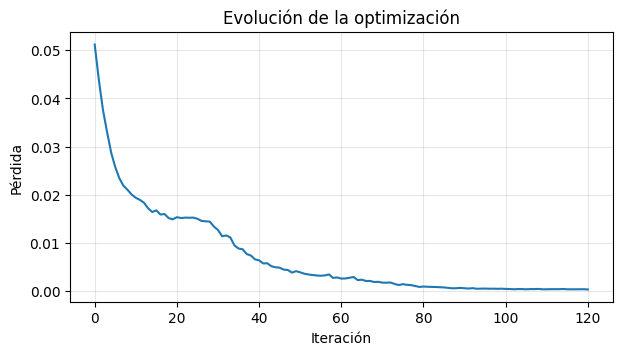

posición inicial optimizada: [0.25049987 0.47677734]
velocidad inicial optimizada: [ 0.42973238 -0.00436945]


In [69]:
learned_init_x, learned_init_v, optimization_history, learned_final_pos = optimize_shot()

plt.figure(figsize=(7, 3.5))
plt.plot(optimization_history)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la optimización")
plt.grid(alpha=0.3)
plt.show()

print("posición inicial optimizada:", learned_init_x.cpu().numpy())
print("velocidad inicial optimizada:", learned_init_v.cpu().numpy())

## Comparación visual

Comparamos el disparo inicial con el disparo optimizado. Lo importante no es solo la pérdida numérica, sino cómo una pequeña modificación de las condiciones iniciales cambia toda la cadena de colisiones.

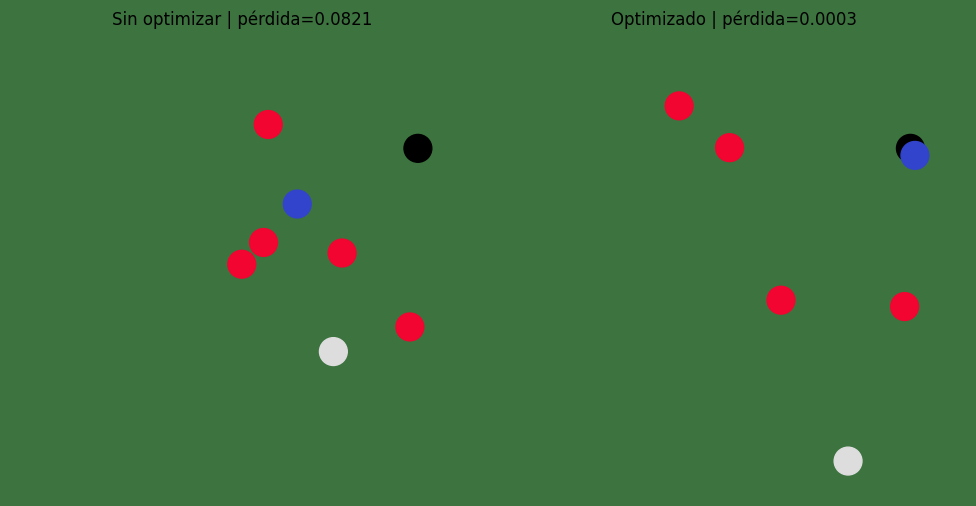

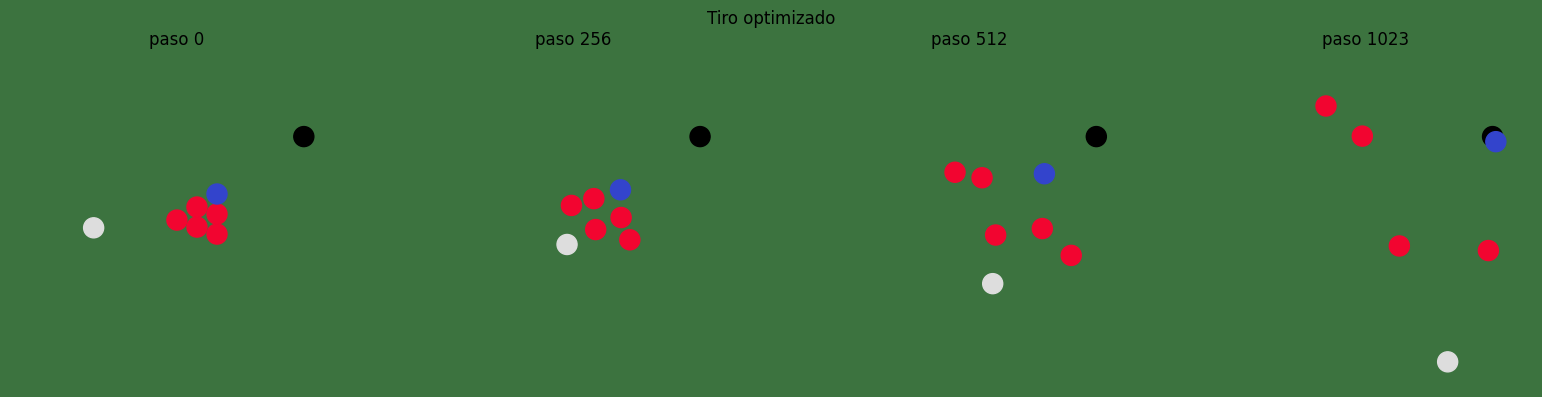

In [72]:
optimized_loss, optimized_final_pos, optimized_history = simulate(learned_init_x, learned_init_v, save_history=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
render_scene(baseline_final_pos, title=f"Sin optimizar | pérdida={baseline_loss.item():.4f}", ax=axes[0])
render_scene(optimized_final_pos, title=f"Optimizado | pérdida={optimized_loss.item():.4f}", ax=axes[1])
plt.tight_layout()
plt.show()

show_snapshots(optimized_history, "Tiro optimizado", [0, 256, 512, 1023])

Adam paso 000 | pérdida=0.016084 | init_x=[0.102      0.33200002] | init_v=[0.28345743 0.10583512]
Adam paso 020 | pérdida=0.005394 | init_x=[0.14215916 0.34695643] | init_v=[0.3230495  0.12738174]
Adam paso 040 | pérdida=0.001355 | init_x=[0.17453717 0.35778317] | init_v=[0.3523669  0.14377782]
Adam paso 060 | pérdida=0.000364 | init_x=[0.18997082 0.3599073 ] | init_v=[0.3652122 0.1497922]
Adam paso 080 | pérdida=0.005399 | init_x=[0.18623516 0.3388869 ] | init_v=[0.36269063 0.13685721]
Adam paso 100 | pérdida=0.000401 | init_x=[0.16951373 0.33796215] | init_v=[0.3509558  0.13857277]
Adam paso 119 | pérdida=0.000441 | init_x=[0.16339909 0.33438316] | init_v=[0.34648514 0.13668703]
LBFGS pérdida inicial: 0.000404
LBFGS pérdida final:   0.000345
Tiempo LBFGS: 6015.78 ms


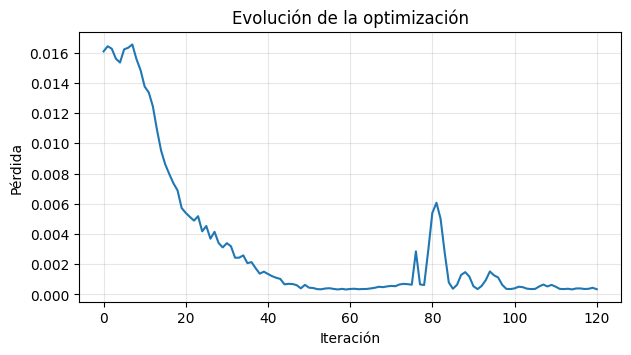

posición inicial optimizada: [0.16261895 0.33451024]
velocidad inicial optimizada: [0.3458693  0.13687654]


In [74]:
learned_init_x, learned_init_v, optimization_history, learned_final_pos = optimize_shot(default_init_x=init_x1, default_init_v=init_v1)

plt.figure(figsize=(7, 3.5))
plt.plot(optimization_history)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la optimización")
plt.grid(alpha=0.3)
plt.show()

print("posición inicial optimizada:", learned_init_x.cpu().numpy())
print("velocidad inicial optimizada:", learned_init_v.cpu().numpy())

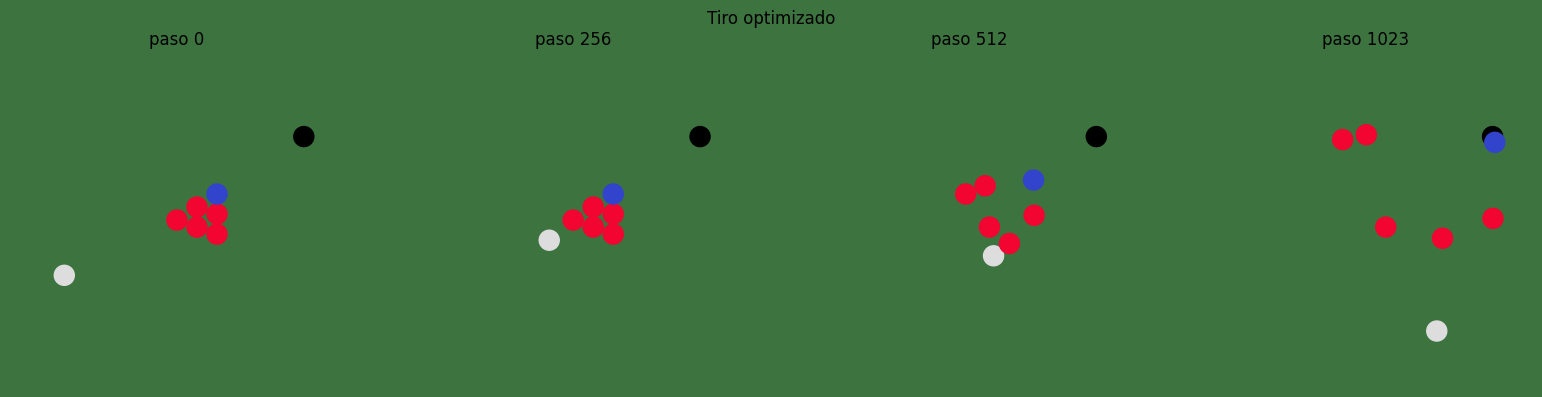

In [76]:
optimized_loss, optimized_final_pos, optimized_history = simulate(learned_init_x, learned_init_v, save_history=True)

show_snapshots(optimized_history, "Tiro optimizado", [0, 256, 512, 1023])